# Statistical Inference & Decision Analysis

## Understanding p-values, likelihood ratios, and real-world impact

---

## Project Overview

This project analyzes hypothesis testing using binomial and normal models to explore how statistical significance, likelihood ratios, and confidence intervals interact.

The goal is to demonstrate that statistically significant results do not always imply strong evidence or meaningful real-world impact.

---

## Methods

- Binomial model for hypothesis testing (n = 400)
- Likelihood ratio analysis comparing alternative hypotheses
- Normal model for confidence intervals
- Simulation and visualization using Python (NumPy, SciPy, Matplotlib)


## Hypothesis Testing with Binomial Model

A test statistic, x, is distributed according to a Binomial distribution with 𝑛 = 400 trials and
some unknown probability of success, 𝜃. As a result of our experiment with 400 trials we
obtain a value for x equal to 217 successes. The null hypothesis is 𝐻0 ∶ 𝜃 = 0.5


In [8]:
%matplotlib inline
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt

n = 400
theta_0 = 0.5
x_obs = 217

# Part (a)
theta_hat = x_obs / n
print(f"Part (a): Estimated probability of success: {theta_hat}")

Part (a): Estimated probability of success: 0.5425


The estimated probability of success is: $$\hat{\theta} = \frac{x}{n} = \frac{217}{400} = 0.5425$$


In [9]:
# Part (b)
p_value = 1 - binom.cdf(x_obs - 1, n, theta_0)
print(f"Part (b): One-sided p-value: {p_value:.4f}")
print(f"Significant at 5% level: {p_value < 0.05}")

x_range = np.arange(170, 241)

alternatives = [0.56, 0.5425, 0.51]

Part (b): One-sided p-value: 0.0494
Significant at 5% level: True


The one-sided p-value is $P(X \geq 217 \mid \theta = 0.5) = 0.0494$. Since $0.0494 < 0.05$, the result **is statistically significant** at the $\alpha = 0.05$ level.

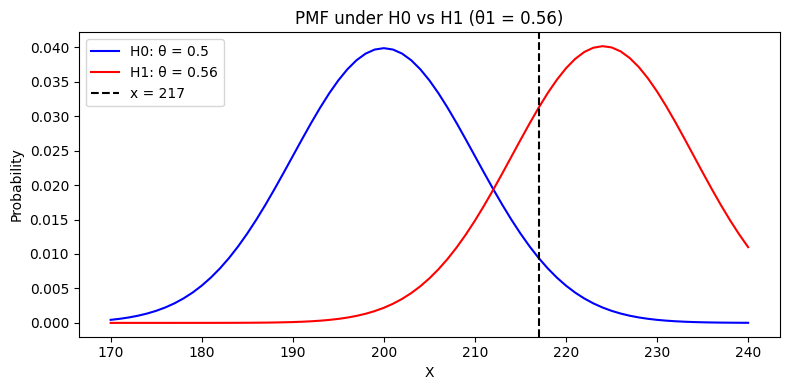

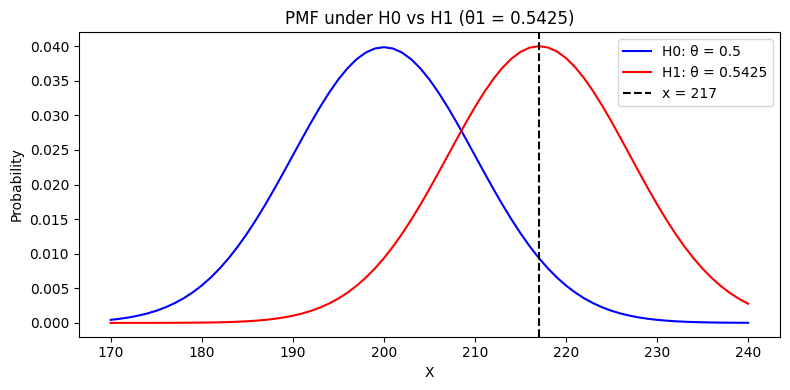

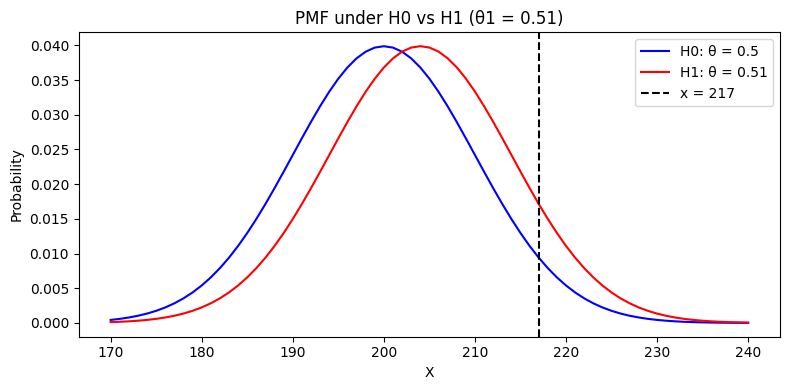

In [10]:
# Part (c) — Three PMF plots
for theta_1 in alternatives:
    pmf_H0 = binom.pmf(x_range, n, theta_0)
    pmf_H1 = binom.pmf(x_range, n, theta_1)

    plt.figure(figsize=(8, 4))
    plt.plot(x_range, pmf_H0, label=f'H0: θ = {theta_0}', color='blue')
    plt.plot(x_range, pmf_H1, label=f'H1: θ = {theta_1}', color='red')
    plt.axvline(x=x_obs, color='black', linestyle='--', label=f'x = {x_obs}')
    plt.xlabel('X')
    plt.ylabel('Probability')
    plt.title(f'PMF under H0 vs H1 (θ1 = {theta_1})')
    plt.legend()
    plt.tight_layout()
    plt.show()

The three plots above show the PMF of $X$ under $H_0: \theta = 0.5$ and each alternative hypothesis, with the observed value $x = 217$ marked by a vertical dashed line.

In [11]:
# Part (d) — Likelihood ratio table
p_H0 = binom.pmf(x_obs, n, theta_0)
print(f"\nP(X=217 | H0) = {p_H0:.6f}\n")

for theta_1 in alternatives:
    p_H1 = binom.pmf(x_obs, n, theta_1)
    LR = p_H1 / p_H0
    print(f"θ1 = {theta_1}: P(X=217|H1) = {p_H1:.6f}, LR = {LR:.4f}")


P(X=217 | H0) = 0.009417

θ1 = 0.56: P(X=217|H1) = 0.031227, LR = 3.3162
θ1 = 0.5425: P(X=217|H1) = 0.040014, LR = 4.2493
θ1 = 0.51: P(X=217|H1) = 0.017160, LR = 1.8223



| | $H_1: \theta = 0.56$ | $H_1: \theta = 0.5425$ | $H_1: \theta = 0.51$ |
|---|---|---|---|
| $P(X=217 \mid H_0)$ | 0.009417 | 0.009417 | 0.009417 |
| $P(X=217 \mid H_1)$ | 0.031227 | 0.040014 | 0.017160 |
| Likelihood Ratio | 3.3162 | 4.2493 | 1.8223 |

**(i)** $P(X=217 \mid H_0) = 0.0094$, which is small. A small p-value guarantees this because rejecting $H_0$ at the 5% level requires the observed data to fall in the tail of $H_0$'s distribution, where probabilities are necessarily low.

**(ii)** The numerator values are also small, ranging from 0.017 to 0.040. The largest numerator is under $\theta_1 = 0.5425$ (0.0400), and the smallest is under $\theta_1 = 0.51$ (0.0172).

**(iii)** The likelihood ratios are 3.32, 4.25, and 1.82 , not large for a "statistically significant" result. The data is only about 3.3× more likely under $\theta_1 = 0.56$, 4.25× more likely under $\theta_1 = 0.5425$, and less than 2× more likely under $\theta_1 = 0.51$ than under $H_0$.

**(iv)** A small p-value means the denominator $P(X=217 \mid H_0)$ is small, the data is unlikely under $H_0$. But if $H_1$ is close to $H_0$, the numerator $P(X=217 \mid H_1)$ will also be small, since both distributions assign low probability to the same tail region. The likelihood ratio is the *ratio* of two small numbers, which need not be large. Statistical significance tells us only that the denominator is small; it says nothing about how much better $H_1$ explains the data.


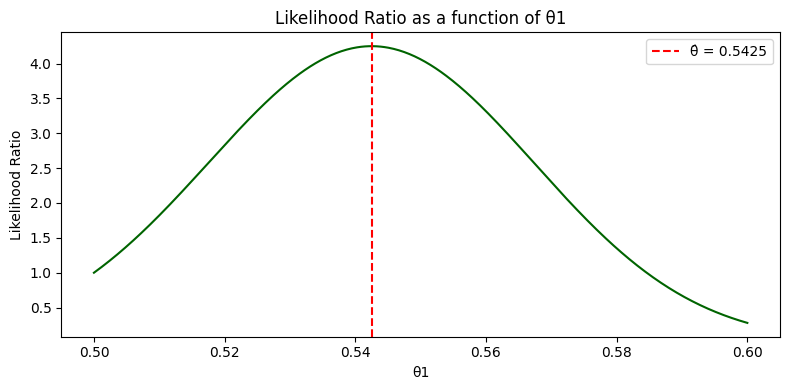


LR maximized at θ1 = 0.5425, Max LR = 4.2493


In [12]:
# Part (e) — LR as a function of theta_1
theta_grid = np.linspace(0.50, 0.60, 500)
LR_grid = binom.pmf(x_obs, n, theta_grid) / p_H0

plt.figure(figsize=(8, 4))
plt.plot(theta_grid, LR_grid, color='darkgreen')
plt.axvline(x=theta_hat, color='red', linestyle='--', label=f'θ̂ = {theta_hat}')
plt.xlabel('θ1')
plt.ylabel('Likelihood Ratio')
plt.title('Likelihood Ratio as a function of θ1')
plt.legend()
plt.tight_layout()
plt.show()

max_LR = LR_grid.max()
max_theta = theta_grid[LR_grid.argmax()]
print(f"\nLR maximized at θ1 = {max_theta:.4f}, Max LR = {max_LR:.4f}")

The LR is maximized at θ₁ = 0.5425, with a maximum LR of 4.2493. This equals θ̂ from Part (a)  the MLE is the alternative that makes the observed data most probable. Even under this most favorable alternative, the data is only about 4.25× more likely than under H₀ modest evidence at best, despite the p-value being "significant."

## Confidence Intervals and Hypothesis Testing

We have $n = 25$ observations from a Normal distribution with unknown mean and known standard deviation $\sigma = 10$. The sample mean estimator $\bar{x}$ is normally distributed with standard deviation $\sigma/\sqrt{n} = 2$. We observe $\bar{x} = 55$.

The two-sided p-value function is:
$$p(\mu) = P\left[\left|\frac{\bar{x} - \mu}{\sigma/\sqrt{n}}\right| \geq \left|\frac{55 - \mu}{\sigma/\sqrt{n}}\right| \mid H: E[x_i] = \mu\right]$$

In [13]:
# Part (a)
from scipy.stats import norm
import numpy as np

sigma = 10
n = 25
x_bar = 55
se = sigma / np.sqrt(n)  # = 2

mu_values = [50, 52, 54, 55, 56, 58, 60]

print(f"{'mu':>6} {'z':>8} {'p(mu)':>10}")
print("-" * 28)
for mu in mu_values:
    z = abs(x_bar - mu) / se
    p = 2 * (1 - norm.cdf(z))
    print(f"{mu:>6} {z:>8.4f} {p:>10.4f}")

    mu        z      p(mu)
----------------------------
    50   2.5000     0.0124
    52   1.5000     0.1336
    54   0.5000     0.6171
    55   0.0000     1.0000
    56   0.5000     0.6171
    58   1.5000     0.1336
    60   2.5000     0.0124


Largest p-value: μ = 55, p(55) = 1.0. This makes sense because when the hypothesized mean equals the observed sample mean, the test statistic is exactly zero, the data is perfectly compatible with that hypothesis.
Smallest p-value: μ = 50 and μ = 60 (tied), p = 0.0124.



- $H_0: \mu = 50$ → $p = 0.0124 < 0.05$ → **Reject**
- $H: \mu = 52$ → $p = 0.1336 > 0.05$ → **Fail to reject**
- $H: \mu = 54$ → $p = 0.6171 > 0.05$ → **Fail to reject**
- $H: \mu = 56$ → $p = 0.6171 > 0.05$ → **Fail to reject**

In [14]:
# Part (c)
z_star = norm.ppf(0.975)  # critical value for 95% CI
lower = x_bar - z_star * se
upper = x_bar + z_star * se
print(f"Critical value z* = {z_star:.4f}")
print(f"95% Confidence Interval: ({lower:.4f}, {upper:.4f})")

Critical value z* = 1.9600
95% Confidence Interval: (51.0801, 58.9199)


We need $p(\mu) > 0.05$, which requires $z = |55 - \mu|/2 < 1.96$. Solving:

$$55 - 1.96 \times 2 < \mu < 55 + 1.96 \times 2$$
$$(51.08,\ 58.92)$$

This interval is called the **95% confidence interval**. From the table in Part (a), the values $\mu = 52, 54, 55, 56, 58$ all have $p(\mu) > 0.05$ and all fall inside $(51.08, 58.92)$, while $\mu = 50$ and $\mu = 60$ have $p(\mu) < 0.05$ and fall outside exactly consistent.

**1. Show $p(\mu)$ is maximized at $\mu = d$:**

$$p(\mu) = 2\left(1 - \Phi\left(\frac{|d - \mu|}{\sigma/\sqrt{n}}\right)\right)$$

This is maximized when $|d - \mu| = 0$, i.e., $\mu = d$. At that point:
$$p(d) = 2(1 - \Phi(0)) = 2(0.5) = 1$$

The sample mean is the hypothesis most compatible with the data because it produces a z-score of exactly zero, the observed result is precisely what that hypothesis predicts.

**2. Show the 95% CI is $d \pm 1.96\,\sigma/\sqrt{n}$:**

Starting from $p(\mu) > 0.05$:
$$2\left(1 - \Phi\left(\frac{|d-\mu|}{\sigma/\sqrt{n}}\right)\right) > 0.05$$
$$\frac{|d-\mu|}{\sigma/\sqrt{n}} < 1.96$$
$$d - 1.96\frac{\sigma}{\sqrt{n}} < \mu < d + 1.96\frac{\sigma}{\sqrt{n}}$$

With $d = 55$ and $\sigma/\sqrt{n} = 2$: $(51.08,\ 58.92)$ ✓ matches Part (c).



**(i)** Rejecting $H_0: \mu = 50$ does not mean we have *shown* the true mean is not 50. It only means that 50 is not very compatible with the observed data, $p(50) = 0.0124$ tells us that if the true mean were 50, data as extreme as ours would occur only 1.24% of the time. That is evidence against 50, but not proof it is wrong.

**(ii)** All values of $\mu$ inside the 95% CI $(51.08, 58.92)$ have $p(\mu) > 0.05$, meaning none of them can be rejected at the 5% level. No single value inside the interval is more "special" than any other they are all equally compatible with the data.

**(iii)** The colleague's conclusion goes too far. While we rejected $\mu = 50$, the confidence interval shows that values like $\mu = 52$ or $\mu = 58$ are perfectly compatible with the data. A more careful statement would be: "The data is inconsistent with a mean of 50 at the 5% significance level, but the true mean plausibly lies anywhere in the range $(51.08, 58.92)$."

## Real-World Implications of Statistical Results

This problem examines the practical implications of confidence intervals, following the recommendation from *Scientists Rise Up Against Statistical Significance* (Nature, 2019).

## Job Training Program

**Results:** Point estimate = $175, 95% CI = ($50, $300), p-value = 0.006

**(i)** The effect size most compatible with the data is the point estimate: **$175 per year**.

**(ii)** All values inside the confidence interval ($50, $300) are reasonably compatible with the data:

- The **largest plausible effect** is $300/year, or about **$25/month**
- The **smallest plausible effect** is $50/year, or about **$4.17/month**
- The point estimate of $175/year is about **$14.58/month**

None of these amounts would meaningfully change a worker's standard of living. Even the most optimistic plausible effect ($25/month) is unlikely to be economically transformative for program participants.

**(iii)** The recommendation to expand the program nationwide is not well-supported by the confidence interval alone. While the result is statistically significant, the entire confidence interval spans modest effects ($50–$300/year). A policy advisor should weigh the cost of nationwide expansion against a salary benefit that could be as small as $50/year per participant. Statistical significance does not imply practical importance.

## Blood Pressure Medication

**Results:** Point estimate = −6 mmHg, 95% CI = (−15, 3) mmHg, p-value = 0.19

**(i)** The effect size most compatible with the data is the point estimate: **−6 mmHg**.

**(ii)** All values inside the confidence interval (−15, 3) mmHg are reasonably compatible with the data:

- The **largest plausible reduction** is 15 mmHg, which **is clinically meaningful** (exceeds the 10 mmHg threshold) and could move a Stage 1 hypertension patient (130 mmHg) back to normal range
- The **smallest plausible effect** is actually a slight *increase* of 3 mmHg, meaning the drug could potentially worsen blood pressure
- The point estimate of −6 mmHg falls below the 10 mmHg threshold for clinical significance

**(iii)** The editor's conclusion is not justified. The confidence interval includes clinically meaningful reductions (up to 15 mmHg), so it would be wrong to conclude the drug "does not work." The non-significant result is largely due to the small sample size ($n = 40$), which produces wide intervals. A more careful statement would be: "The study was underpowered to detect a clinically meaningful effect, a larger trial is needed before concluding the drug is ineffective."

## Reflection

Paradoxically, the data from the **blood pressure study (Part b)** is more useful for practical decision-making, despite being statistically non-significant. Its wide confidence interval honestly conveys uncertainty and reveals that a clinically meaningful effect is still plausible pointing clearly toward the need for a larger trial.

The **job training study (Part a)**, while statistically significant, tells us the effect is real but small. Its narrow confidence interval rules out large benefits, which is actually important information for a cost-benefit analysis.

The general lesson is that **statistical significance and practical importance are separate questions**. A result can be statistically significant but practically trivial (Part a), or statistically non-significant but practically inconclusive due to insufficient sample size (Part b). Confidence intervals force us to think about the full range of plausible effect sizes, which is what actually matters for real decisions.

## Key Findings

- A statistically significant p-value (0.0494) provided only modest evidence, with likelihood ratios between 1.8 and 4.25  
- Likelihood ratios showed that the observed data was only about 4× more likely under the best alternative hypothesis  
- Confidence intervals provide a range of plausible values rather than a single true parameter  
- Real-world examples showed that statistically significant results may still have negligible practical impact  
- Statistical significance and economic relevance must be evaluated separately  

## References

Bayarri, M.J., Benjamin, D.J., Berger, J.O., and Sellke, T.M. (2016). Rejection odds and rejection ratios: A proposal for statistical practice in testing hypotheses. *Journal of Mathematical Psychology*, 72, 90–103. https://pmc.ncbi.nlm.nih.gov/articles/PMC4858512/

Amrhein, V., Greenland, S., and McShane, B. (2019). Scientists rise up against statistical significance. *Nature*, 567, 305–307.

Frost, J. Statistics By Jim: Interpreting P-values. Retrieved April 2026, from https://statisticsbyjim.com/hypothesis-testing/interpreting-p-values/

Python packages used:
- NumPy (Harris et al., 2020)
- SciPy (Virtanen et al., 2020)
- Matplotlib (Hunter, 2007)

Claude (Anthropic). AI assistant used for coding guidance and conceptual explanations. https://claude.ai